In [1]:
import numpy as np

In [2]:
!pip install matplotlib

You should consider upgrading via the 'C:\Users\KIIT\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
import matplotlib.pyplot as plt

In [4]:
import tensorflow as tf

In [5]:
import tensorflow_datasets as tfds
from PIL import Image, ImageDraw, ImageFont

In [6]:
im_width = 75
im_height = 75
use_normalized_coordinates = True

In [7]:
def draw_bounding_boxes_on_image_array(image, boxes, color=['red'], thickness=1, display_str_list=None):

    if display_str_list is None:
        display_str_list = []

    image_pil = Image.fromarray(image)
    rgbimg = Image.new("RGB", image_pil.size)
    rgbimg.paste(image_pil)

    draw_bounding_boxes_on_image(rgbimg, boxes, color, thickness, display_str_list)

    return np.array(rgbimg)

In [8]:
def draw_bounding_boxes_on_image(image, boxes, color=[], thickness=1, display_str_list=()):
    
    boxes_shape = boxes.shape
    if not boxes_shape:
        return
    
    if len(boxes_shape) != 2 or boxes_shape[1] != 4:
        raise ValueError('Input must be of size [N, 4]')
    
    for i in range(boxes_shape[0]):
        draw_bounding_box_on_image(
            image,
            boxes[i, 1],
            boxes[i, 0],
            boxes[i, 3],
            boxes[i, 2],
            color[i],
            thickness,
            display_str_list[i]
        )

In [9]:
def draw_bounding_box_on_image(image, ymin, xmin, ymax, xmax,
                               color='red', thickness=1,
                               use_normalized_coordinates=True):

    draw = ImageDraw.Draw(image)
    im_width, im_height = image.size

    if use_normalized_coordinates:
        (left, right, top, bottom) = (
            xmin * im_width,
            xmax * im_width,
            ymin * im_height,
            ymax * im_height
        )
    else:
        (left, right, top, bottom) = (xmin, xmax, ymin, ymax)

    draw.line(
        [(left, top), (left, bottom), (right, bottom),
         (right, top), (left, top)],
        width=thickness,
        fill=color
    )

In [10]:
def dataset_to_numpy_util(training_dataset, validation_dataset, N):

    batch_train_ds = training_dataset.unbatch().batch(N)

    if tf.executing_eagerly():

        for validation_digits, (validation_labels, validation_bboxes) in validation_dataset:
            validation_digits = validation_digits.numpy()
            validation_labels = validation_labels.numpy()
            validation_bboxes = validation_bboxes.numpy()
            break

        for training_digits, (training_labels, training_bboxes) in batch_train_ds:
            training_digits = training_digits.numpy()
            training_labels = training_labels.numpy()
            training_bboxes = training_bboxes.numpy()
            break

    validation_labels = np.argmax(validation_labels, axis=1)
    training_labels = np.argmax(training_labels, axis=1)

    return (training_digits, training_labels, training_bboxes,
            validation_digits, validation_labels, validation_bboxes)

In [11]:
import os
import matplotlib
from PIL import Image, ImageDraw, ImageFont

MATPLOTLIB_FONT_DIR = os.path.join(os.path.dirname(matplotlib.__file__), "mpl-data/fonts/ttf")

def create_digits(n):
    font_labels = []

    img = Image.new('LA', (75 * n, 75), color=(0, 255))

    font1 = ImageFont.truetype(os.path.join(MATPLOTLIB_FONT_DIR, 'DejaVuSansMono-Oblique.ttf'), 25)
    font2 = ImageFont.truetype(os.path.join(MATPLOTLIB_FONT_DIR, 'STIXGeneral.ttf'), 25)

    d = ImageDraw.Draw(img)

    for i in range(n):
        font_labels.append(i % 10)
        d.text((7 + i * 75, 0),
               str(i % 10),
               fill=(255, 255),
               font=font1 if i < 10 else font2)

    font_digits = np.array(img.getdata(), np.float32)[:, 0] / 255.0

    font_digits = np.reshape(
        np.stack(np.split(np.reshape(font_digits, [75, 75 * n]), n, axis=1), axis=0),
        [n, 75, 75]
    )

    return font_digits, font_labels

In [33]:

def display_digits_with_boxes(digits, predictions, labels,
                              pred_bboxes, bboxes, iou, title):

    n = 10

    indexes = np.random.choice(len(predictions), size=n)

    n_digits = digits[indexes]
    n_predictions = predictions[indexes]
    n_labels = labels[indexes]

    n_iou = []
    if len(iou) > 0:
        n_iou = iou[indexes]

    n_pred_bboxes = []
    if len(pred_bboxes) > 0:
        n_pred_bboxes = pred_bboxes[indexes]

    n_bboxes = []
    if len(bboxes) > 0:
        n_bboxes = bboxes[indexes]

    n_digits = n_digits * 255.0
    n_digits = n_digits.reshape(n, 75, 75)

    fig = plt.figure(figsize=(20, 4))
    plt.title(title)
    plt.xticks([])
    plt.yticks([])

    for i in range(n):
        ax = fig.add_subplot(1, 10, i + 1)

        boxes_to_plot = []

        if len(pred_bboxes) > i:
            boxes_to_plot.append(n_pred_bboxes[i])

        if len(bboxes) > i:
            boxes_to_plot.append(n_bboxes[i])

        im_to_draw = draw_bounding_boxes_on_image_array(
            image=n_digits[i],
            boxes=np.array(boxes_to_plot),
            color=['red', 'green'],
            display_str_list=['True', 'Pred']
        )

        plt.imshow(im_to_draw, cmap="gray")

        ax.set_xlabel(str(n_predictions[i]))

        confidence = np.max(prediction[0][indexes[i]])
        ax.set_title(f"{confidence:.2f}")

        if n_predictions[i] != n_labels[i]:
            ax.xaxis.label.set_color("red")

        plt.xticks([])
        plt.yticks([])

        if len(iou) > i:
            color = "black"
            if n_iou[i] < iou_threshold:
                color = "red"

            ax.text(0.2, -0.3,
                    "iou: %.2f" % n_iou[i],
                    color=color,
                    transform=ax.transAxes)

    plt.show()

In [31]:
def plot_metrics(metric_name, title):
    plt.title(title)
    plt.plot(history.history[metric_name], color="blue", label=metric_name)
    plt.plot(history.history["val_" + metric_name], color="green", label="val_" + metric_name)
    plt.legend()
    plt.show()

In [13]:
strategy = tf.distribute.get_strategy()
strategy.num_replicas_in_sync

1

In [14]:
BATCH_SIZE = 64 * strategy.num_replicas_in_sync

In [34]:
def read_image_tfds(image, label):

    xmin = tf.random.uniform((), 0, 48, dtype=tf.int32)
    ymin = tf.random.uniform((), 0, 48, dtype=tf.int32)

    image = tf.reshape(image, (28, 28, 1))
    image = tf.image.pad_to_bounding_box(image, ymin, xmin, 75, 75)

    image = tf.cast(image, tf.float32) / 255.0

    image = tf.image.random_brightness(image, 0.3)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)

    xmin = tf.cast(xmin, tf.float32)
    ymin = tf.cast(ymin, tf.float32)

    xmax = (xmin + 28) / 75
    ymax = (ymin + 28) / 75
    xmin = xmin / 75
    ymin = ymin / 75

    return image, (tf.one_hot(label, 10), [xmin, ymin, xmax, ymax])

In [16]:
def get_training_dataset():

    with strategy.scope():
        dataset = tfds.load("mnist", split="train",
                            as_supervised=True, try_gcs=True)

        dataset = dataset.map(read_image_tfds, num_parallel_calls=16)
        dataset = dataset.shuffle(5000, reshuffle_each_iteration=True)
        dataset = dataset.repeat()
        dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [17]:
def get_validation_dataset():

    with strategy.scope():
        dataset = tfds.load("mnist", split="test",
                            as_supervised=True, try_gcs=True)

        dataset = dataset.map(read_image_tfds, num_parallel_calls=16)
        dataset = dataset.batch(10000, drop_remainder=True)

    return dataset

In [18]:
with strategy.scope():
    training_dataset = get_training_dataset()
    validation_dataset = get_validation_dataset()

In [19]:
with strategy.scope():
    training_dataset = get_training_dataset()
    validation_dataset = get_validation_dataset()

In [20]:
(training_digits, training_labels, training_bboxes,
validation_digits, validation_labels, validation_bboxes) = dataset_to_numpy_util(training_dataset, validation_dataset, 10)

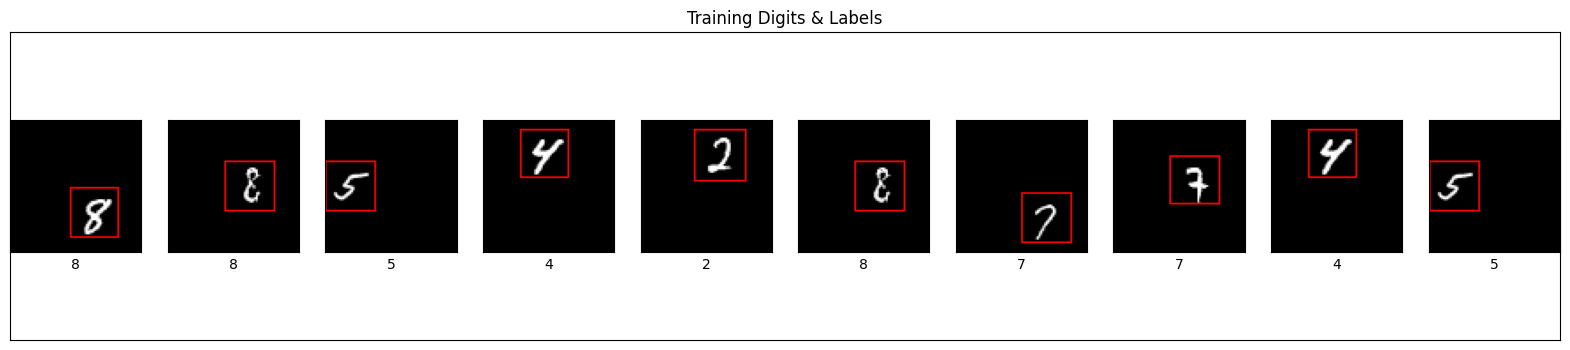

In [21]:
display_digits_with_boxes(
    training_digits,
    training_labels,   
    training_labels,  
    np.array([]),      
    training_bboxes,
    np.array([]),    
    "Training Digits & Labels"
)

In [39]:
def intersection_over_union(pred_box, true_box):

    xmin_pred, ymin_pred, xmax_pred, ymax_pred = np.split(pred_box, 4, axis=1)
    xmin_true, ymin_true, xmax_true, ymax_true = np.split(true_box, 4, axis=1)

    smoothing_factor = 1e-10

    xmin_overlap = np.maximum(xmin_pred, xmin_true)
    xmax_overlap = np.minimum(xmax_pred, xmax_true)
    ymin_overlap = np.maximum(ymin_pred, ymin_true)
    ymax_overlap = np.minimum(ymax_pred, ymax_true)

    overlap_area = (
        np.maximum(xmax_overlap - xmin_overlap, 0) *
        np.maximum(ymax_overlap - ymin_overlap, 0)
    )

    pred_area = (xmax_pred - xmin_pred) * (ymax_pred - ymin_pred)
    true_area = (xmax_true - xmin_true) * (ymax_true - ymin_true)

    union_area = pred_area + true_area - overlap_area

    iou = (overlap_area + smoothing_factor) / (union_area + smoothing_factor)

    return iou

157/157 [==============================] - 5s 29ms/step


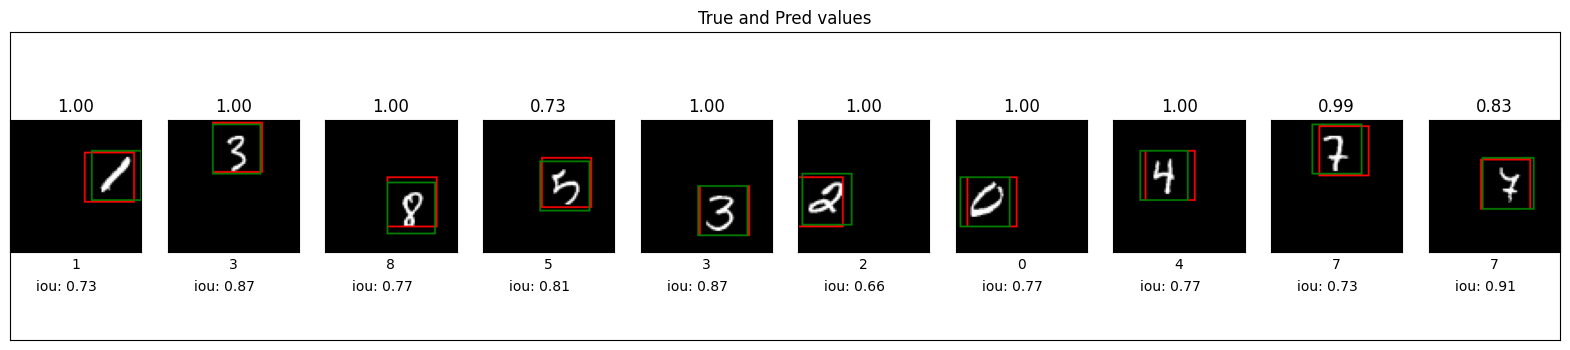

In [41]:
prediction = model.predict(validation_digits, batch_size=64)

predicted_labels = np.argmax(prediction[0], axis=1)
prediction_boxes = prediction[1]

iou = intersection_over_union(prediction_boxes, validation_bboxes)
iou_threshold = 0.6

display_digits_with_boxes(
    validation_digits,
    predicted_labels,
    validation_labels,
    prediction_boxes,
    validation_bboxes,
    iou,
    "True and Pred values"
)

In [23]:
def feature_extractor(inputs):
    x = tf.keras.layers.Conv2D(16, kernel_size=3, activation='relu')(inputs)
    x = tf.keras.layers.AveragePooling2D((2,2))(x)

    x = tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu')(x)
    x = tf.keras.layers.AveragePooling2D((2,2))(x)

    x = tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu')(x)
    x = tf.keras.layers.AveragePooling2D((2,2))(x)

    return x

In [24]:
def dense_layers(inputs):
    x = tf.keras.layers.Flatten()(inputs)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    return x

In [25]:
def classifier(inputs):
    classification_output = tf.keras.layers.Dense(
        10,
        activation="softmax",
        name="classification"
    )(inputs)
    return classification_output

In [26]:
def bounding_box_regression(inputs):
    bounding_box_regression_output = tf.keras.layers.Dense(
        4,
        name="bounding_box"
    )(inputs)
    return bounding_box_regression_output

In [27]:
def final_model(inputs):
    feature_cnn = feature_extractor(inputs)
    dense_output = dense_layers(feature_cnn)

    classification_output = classifier(dense_output)
    bounding_box_output = bounding_box_regression(dense_output)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=[classification_output, bounding_box_output]
    )

    return model

In [28]:
def define_and_compile_model(inputs):
    model = final_model(inputs)

    model.compile(
        optimizer="adam",
        loss={
            "classification": "categorical_crossentropy",
            "bounding_box": "mse"
        },
        metrics={
            "classification": "accuracy",
            "bounding_box": "mse"
        }
    )

    return model

In [29]:
with strategy.scope():
    inputs = tf.keras.Input(shape=(75, 75, 1))
    model = define_and_compile_model(inputs)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 75, 75, 1)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 73, 73, 16)   160         ['input_1[0][0]']                
                                                                                                  
 average_pooling2d (AveragePool  (None, 36, 36, 16)  0           ['conv2d[0][0]']                 
 ing2D)                                                                                           
                                                                                                  
 conv2d_1 (Conv2D)              (None, 34, 34, 32)   4640        ['average_pooling2d[0][0]']  

In [30]:
EPOCHS = 20

steps_per_epoch = 60000 // BATCH_SIZE

history = model.fit(
    training_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_data=validation_dataset,
    validation_steps=1,
    epochs=EPOCHS
)

loss, classification_loss, bounding_box_loss, classification_acc, bounding_box_mse = model.evaluate(
    validation_dataset,
    steps=1
)

print("\nValidation accuracy:", classification_acc)
print("\n")

Epoch 1/20
937/937 [==============================] - 93s 98ms/step - loss: 0.9318 - classification_loss: 0.9139 - bounding_box_loss: 0.0179 - classification_accuracy: 0.6838 - bounding_box_mse: 0.0179 - val_loss: 0.2906 - val_classification_loss: 0.2815 - val_bounding_box_loss: 0.0091 - val_classification_accuracy: 0.9123 - val_bounding_box_mse: 0.0091
Epoch 2/20
937/937 [==============================] - 90s 96ms/step - loss: 0.2533 - classification_loss: 0.2465 - bounding_box_loss: 0.0068 - classification_accuracy: 0.9251 - bounding_box_mse: 0.0068 - val_loss: 0.1694 - val_classification_loss: 0.1651 - val_bounding_box_loss: 0.0044 - val_classification_accuracy: 0.9515 - val_bounding_box_mse: 0.0044
Epoch 3/20
937/937 [==============================] - 98s 105ms/step - loss: 0.1815 - classification_loss: 0.1776 - bounding_box_loss: 0.0039 - classification_accuracy: 0.9467 - bounding_box_mse: 0.0039 - val_loss: 0.1275 - val_classification_loss: 0.1249 - val_bounding_box_loss: 0.0027 

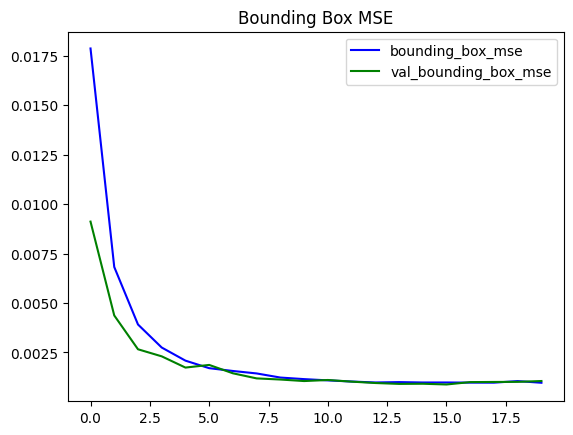

In [32]:
plot_metrics("bounding_box_mse", "Bounding Box MSE")

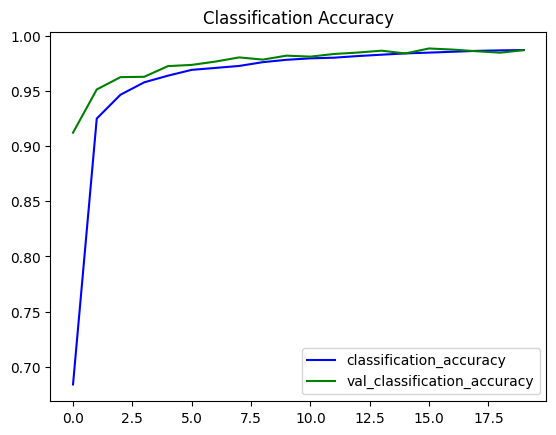

In [42]:
plot_metrics("classification_accuracy", "Classification Accuracy")

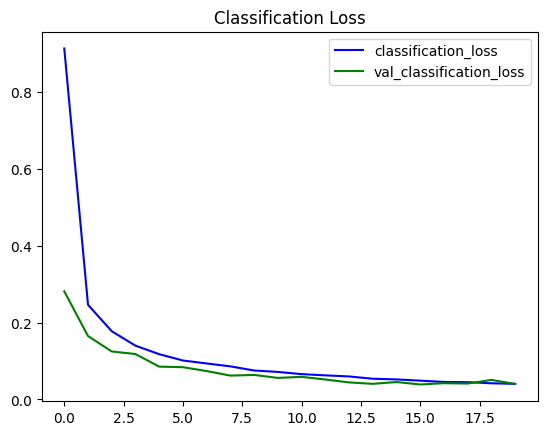

In [43]:
plot_metrics("classification_loss", "Classification Loss")

In [44]:
def intersection_over_union(pred_box, true_box):

    xmin_pred, ymin_pred, xmax_pred, ymax_pred = np.split(pred_box, 4, axis=1)
    xmin_true, ymin_true, xmax_true, ymax_true = np.split(true_box, 4, axis=1)

    smoothing_factor = 1e-10

    xmin_overlap = np.maximum(xmin_pred, xmin_true)
    xmax_overlap = np.minimum(xmax_pred, xmax_true)
    ymin_overlap = np.maximum(ymin_pred, ymin_true)
    ymax_overlap = np.minimum(ymax_pred, ymax_true)

    pred_box_area = (xmax_pred - xmin_pred) * (ymax_pred - ymin_pred)
    true_box_area = (xmax_true - xmin_true) * (ymax_true - ymin_true)

    overlap_area = (
        np.maximum(xmax_overlap - xmin_overlap, 0) *
        np.maximum(ymax_overlap - ymin_overlap, 0)
    )

    union_area = pred_box_area + true_box_area - overlap_area

    iou = (overlap_area + smoothing_factor) / (union_area + smoothing_factor)

    return iou

In [45]:
prediction = model.predict(validation_digits, batch_size=64)

predicted_labels = np.argmax(prediction[0], axis=1)
prediction_boxes = prediction[1]

157/157 [==============================] - 4s 27ms/step


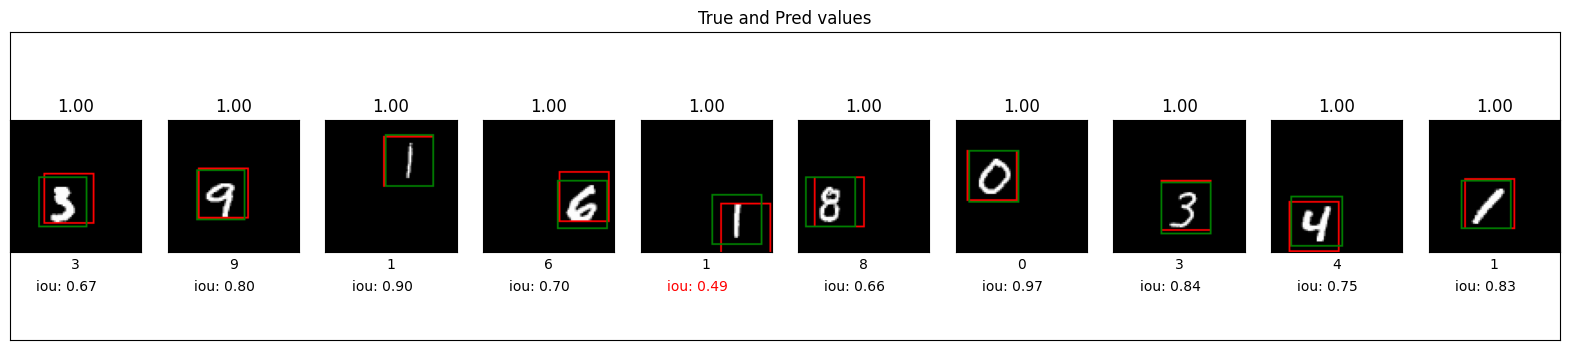

In [46]:
iou = intersection_over_union(prediction_boxes, validation_bboxes)

iou_threshold = 0.6

display_digits_with_boxes(
    validation_digits,
    predicted_labels,
    validation_labels,
    prediction_boxes,
    validation_bboxes,
    iou,
    "True and Pred values"
)

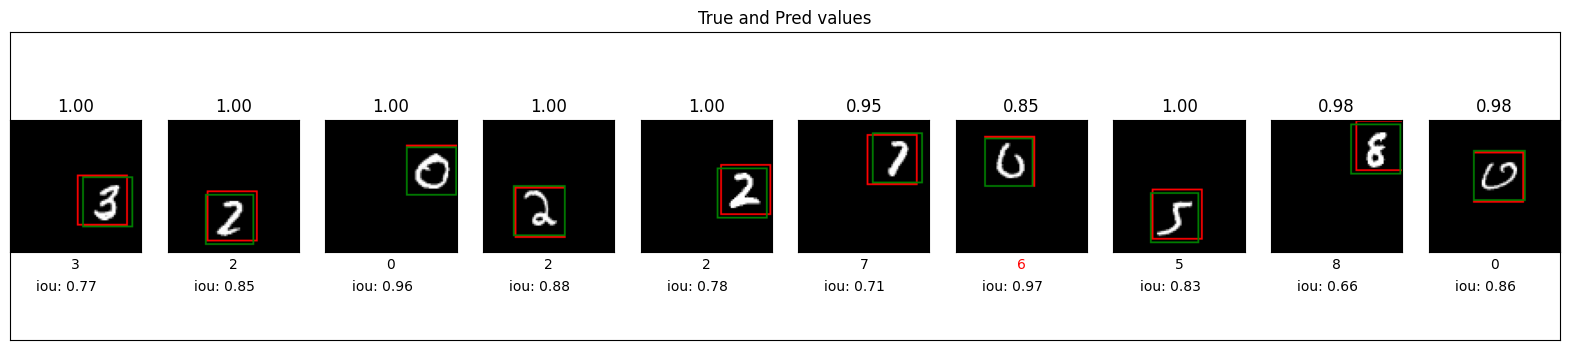

In [47]:
display_digits_with_boxes(
    validation_digits,
    predicted_labels,
    validation_labels,
    prediction_boxes,
    validation_bboxes,
    iou,
    "True and Pred values"
)